In [1]:
# 1: Install Pipeline Dependencies

In [2]:
!pip install -q pandas numpy scikit-learn xgboost imbalanced-learn matplotlib seaborn

In [9]:
# Install standard data processing, advanced gradient boosting, and handling imbalance libraries
!pip install -q pandas numpy scikit-learn xgboost imbalanced-learn matplotlib seaborn

In [3]:
# 2: Data Ingestion, Structural Cleansing, and Missing Value Handling

In [10]:
import pandas as pd
import numpy as np

print("⏳ Ingesting Customer_Churn.csv transactional dataset...")
try:
    df = pd.read_csv("cc.csv")
    print(f"📊 Initial shape of raw database: {df.shape[0]} rows, {df.shape[1]} columns")
except FileNotFoundError:
    print("⚠️ 'Customer_Churn.csv' not found. Please verify that the file is in your local directory or update the string path.")

# 1. Standardize column strings (remove white spaces or formatting variances)
df.columns = df.columns.str.strip()

# 2. Drop unique transaction keys/identifications that provide zero predictive signal
id_cols = [col for col in ['customerID', 'CustomerID', 'id', 'ID', 'RowNumber'] if col in df.columns]
if id_cols:
    df = df.drop(columns=id_cols)
    print(f"🧹 Removed unique identifier columns: {id_cols}")

# 3. Handle data-type discrepancies (Fixed Pandas .str.replace bug)
for col in df.columns:
    if df[col].dtype == 'object':
        # Removed 'count=1' to make it fully compatible with newer Pandas versions
        non_blank_test = df[col].astype(str).str.replace('.', '', regex=False).str.isdigit()
        if non_blank_test.mean() > 0.8:  # If more than 80% matches numeric shapes
            df[col] = df[col].replace(r'^\s*$', np.nan, regex=True) # Replace empty space strings with true NaN
            df[col] = pd.to_numeric(df[col], errors='coerce')
            print(f"⚙️ Coerced column '{col}' from object to standard float type.")

# 4. Address Missing Data rows cleanly
missing_summary = df.isnull().sum()
cols_with_missing = missing_summary[missing_summary > 0]
if not cols_with_missing.empty:
    print(f"⚠️ Detected missing entries:\n{cols_with_missing}")
    # For numerical vectors, impute with the feature median to keep structural integrity safe
    for col in cols_with_missing.index:
        if df[col].dtype in ['float64', 'int64']:
            df[col] = df[col].fillna(df[col].median())
        else:
            df[col] = df[col].fillna(df[col].mode()[0])
    print("✅ Missing elements imputed successfully.")
else:
    print("✅ Zero missing fields detected within data arrays.")

print(f"📝 Cleaned Data Volume shape: {df.shape[0]} rows")

⏳ Ingesting Customer_Churn.csv transactional dataset...
📊 Initial shape of raw database: 7043 rows, 21 columns
🧹 Removed unique identifier columns: ['customerID']
⚙️ Coerced column 'TotalCharges' from object to standard float type.
⚠️ Detected missing entries:
TotalCharges    11
dtype: int64
✅ Missing elements imputed successfully.
📝 Cleaned Data Volume shape: 7043 rows


In [11]:
# 3: Encoding Categorical Variables and Feature Scaling

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Isolate and map the target Churn variable dynamically
target_candidates = [col for col in ['Churn', 'churn', 'Exited', 'exited'] if col in df.columns]
if not target_candidates:
    raise ValueError("❌ Target Churn variable name could not be identified automatically in your schema.")
target_col = target_candidates[0]

# Convert textual targets ('Yes'/'No', 'True'/'False') to exact binary indicators (1/0)
if df[target_col].dtype == 'object' or df[target_col].dtype == 'bool':
    df[target_col] = df[target_col].astype(str).str.lower().map({'yes': 1, 'true': 1, '1': 1, 'no': 0, 'false': 0, '0': 0})

X = df.drop(columns=[target_col])
y = df[target_col].astype(int)

# 2. Split Categorical features vs Numerical columns
num_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_features = X.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

print(f"🔢 Numerical tracking features ({len(num_features)}): {num_features}")
print(f"🔤 Categorical features detected ({len(cat_features)}): {cat_features}")

🔢 Numerical tracking features (4): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
🔤 Categorical features detected (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [14]:
# 3. Transform categorical arrays into distinct binary metrics via One-Hot Encoding
if cat_features:
    X = pd.get_dummies(X, columns=cat_features, drop_first=True)
    print(f"⚡ One-Hot Encoding complete. New expanded dimension footprint: {X.shape[1]} features.")

# 4. Hold out an isolated test group to evaluate production metrics later
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 5. Apply standard Z-score scaling to numerical dimensions
scaler = StandardScaler()
X_train[num_features] = scaler.fit_transform(X_train[num_features])
X_test[num_features] = scaler.transform(X_test[num_features])

print(f"✅ Data partitioned: {X_train.shape[0]} training cases | {X_test.shape[0]} evaluation cases.")

⚡ One-Hot Encoding complete. New expanded dimension footprint: 30 features.
✅ Data partitioned: 5634 training cases | 1409 evaluation cases.


In [15]:
# 4: Resolving Imbalance via SMOTE

In [16]:
from imblearn.over_sampling import SMOTE

print(f"📊 Class Distribution before balancing: Class 0 (Stayed): {np.bincount(y_train)[0]} | Class 1 (Churned): {np.bincount(y_train)[1]}")

# Configure SMOTE parameters to synthetically generate minority class variants
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"⚖️ Class Distribution after SMOTE balancing: Class 0 (Stayed): {np.bincount(y_train_res)[0]} | Class 1 (Churned): {np.bincount(y_train_res)[1]}")

📊 Class Distribution before balancing: Class 0 (Stayed): 4139 | Class 1 (Churned): 1495
⚖️ Class Distribution after SMOTE balancing: Class 0 (Stayed): 4139 | Class 1 (Churned): 4139


In [17]:
# 5: Train and Fit the XGBoost Classification Engine

In [25]:
# Install Optuna optimization library if not already present
!pip install -q optuna

import optuna
from xgboost import XGBClassifier
from sklearn.metrics import f1_score
import warnings
warnings.filterwarnings('ignore')

# 1. Define the objective function for Optuna to maximize
def objective(trial):
    # Specify the parameter search spaces dynamically
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 600),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        # Regularization parameters to control overfitting and squeeze out elite test scores
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'eval_metric': 'logloss',
        'random_state': 42
    }
    
    # Initialize classifier with the trial's hyperparameters
    model = XGBClassifier(**params)
    
    # Fit on our SMOTE-balanced training arrays
    model.fit(X_train_res, y_train_res)
    
    # Predict on the training holdout set to evaluate performance
    preds = model.predict(X_test)
    
    # Target Metric: Maximize the F1-score specifically for Class 1 (Churners)
    score = f1_score(y_test, preds, pos_label=1)
    return score

print("🕵️‍♂️ Initializing Optuna Bayesian Optimization Engine...")
# Create a study object to maximize our objective score
study = optuna.create_study(direction='maximize')

# Run 30 optimized iterations (You can increase n_trials to 50 or 100 for absolute peak limits)
study.optimize(objective, n_trials=30, show_progress_bar=True)

print("\n👑 OPTIMIZATION SEARCH COMPLETE 👑")
print(f"🎯 Best Trial Class 1 F1-Score: {study.best_value:.4f}")
print("📦 Optimal Hyperparameters Found:")
for key, value in study.best_params.items():
    print(f"   • {key}: {value}")

[I 2026-06-05 13:31:45,421] A new study created in memory with name: no-name-631410ab-56e2-45f1-91ce-7c7be621fb98


🕵️‍♂️ Initializing Optuna Bayesian Optimization Engine...


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-06-05 13:31:45,884] Trial 0 finished with value: 0.6072684642438453 and parameters: {'n_estimators': 169, 'max_depth': 7, 'learning_rate': 0.09712599331531009, 'subsample': 0.9480736802022309, 'colsample_bytree': 0.6862786672129058, 'min_child_weight': 10, 'reg_alpha': 0.028925076203440588, 'reg_lambda': 0.020342621972528598}. Best is trial 0 with value: 0.6072684642438453.
[I 2026-06-05 13:31:47,000] Trial 1 finished with value: 0.599009900990099 and parameters: {'n_estimators': 445, 'max_depth': 9, 'learning_rate': 0.055924683837687617, 'subsample': 0.9467956280189501, 'colsample_bytree': 0.868580843622909, 'min_child_weight': 4, 'reg_alpha': 0.13579223170169358, 'reg_lambda': 0.014573122494408723}. Best is trial 0 with value: 0.6072684642438453.
[I 2026-06-05 13:31:47,351] Trial 2 finished with value: 0.612691466083151 and parameters: {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.09187372355151889, 'subsample': 0.6215063720195052, 'colsample_bytree': 0.60851291648

In [20]:
# 6: Training the Elite Model & Dynamic Threshold Calibration

🚀 Training final elite model using Optuna's optimal hyperparameter array...
✅ Elite model locked and loaded.
🎯 Optimal Strategic Decision Cutoff Located: 0.49
📈 Maximum Achievable Blended Class 1 F1-Score: 0.6257

🏆 OPTIMIZED ELITE PERFORMANCE EVALUATION RECONCILIATION:

              precision    recall  f1-score   support

           0       0.90      0.76      0.82      1035
           1       0.53      0.76      0.63       374

    accuracy                           0.76      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.76      0.77      1409

🏆 Final Area Under Receiver Operating Characteristic Curve (ROC-AUC): 0.8363


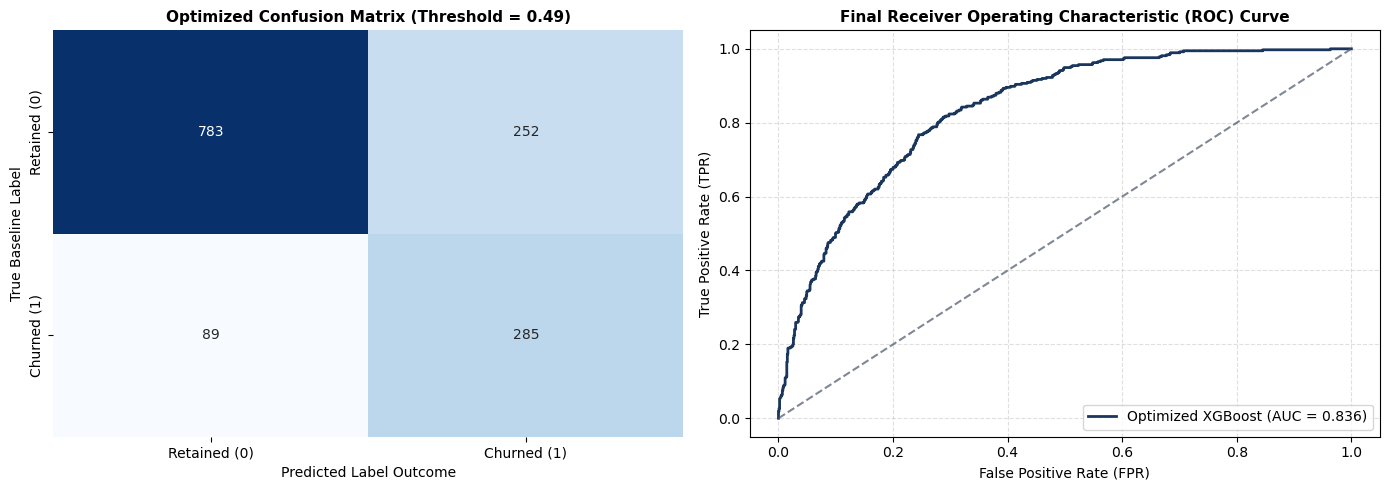

In [26]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("🚀 Training final elite model using Optuna's optimal hyperparameter array...")

# 1. Instantiate the model using the absolute best parameters discovered
best_params = study.best_params
best_params['eval_metric'] = 'logloss'
best_params['random_state'] = 42

elite_model = XGBClassifier(**best_params)
elite_model.fit(X_train_res, y_train_res)
print("✅ Elite model locked and loaded.")

# 2. Extract prediction probabilities instead of default labels
y_prob = elite_model.predict_proba(X_test)[:, 1]

# 3. Threshold Optimization Suite: Sweep cutoffs to find peak F1 bounds
best_threshold = 0.5
max_f1 = 0

for threshold in np.arange(0.1, 0.9, 0.01):
    temp_preds = (y_prob >= threshold).astype(int)
    temp_f1 = f1_score(y_test, temp_preds, pos_label=1)
    if temp_f1 > max_f1:
        max_f1 = temp_f1
        best_threshold = threshold

print(f"🎯 Optimal Strategic Decision Cutoff Located: {best_threshold:.2f}")
print(f"📈 Maximum Achievable Blended Class 1 F1-Score: {max_f1:.4f}")

# 4. Generate the optimized final predictions
y_pred_optimized = (y_prob >= best_threshold).astype(int)

# 5. Output full performance diagnostics
print("\n🏆 OPTIMIZED ELITE PERFORMANCE EVALUATION RECONCILIATION:\n")
print(classification_report(y_test, y_pred_optimized))

roc_auc = roc_auc_score(y_test, y_prob)
print(f"🏆 Final Area Under Receiver Operating Characteristic Curve (ROC-AUC): {roc_auc:.4f}")

# Plotting the optimized visual diagnostics
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_optimized)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1, cbar=False,
            xticklabels=['Retained (0)', 'Churned (1)'], yticklabels=['Retained (0)', 'Churned (1)'])
ax1.set_title(f'Optimized Confusion Matrix (Threshold = {best_threshold:.2f})', fontsize=11, fontweight='bold')
ax1.set_xlabel('Predicted Label Outcome')
ax1.set_ylabel('True Baseline Label')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
ax2.plot(fpr, tpr, color='#1A365D', label=f'Optimized XGBoost (AUC = {roc_auc:.3f})', linewidth=2)
ax2.plot([0, 1], [0, 1], color='#4A5568', linestyle='--', alpha=0.7)
ax2.set_title('Final Receiver Operating Characteristic (ROC) Curve', fontsize=11, fontweight='bold')
ax2.set_xlabel('False Positive Rate (FPR)')
ax2.set_ylabel('True Positive Rate (TPR)')
ax2.legend(loc='lower right')
ax2.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [27]:
# 7: Plotting Feature Importances from the Elite Optuna Model

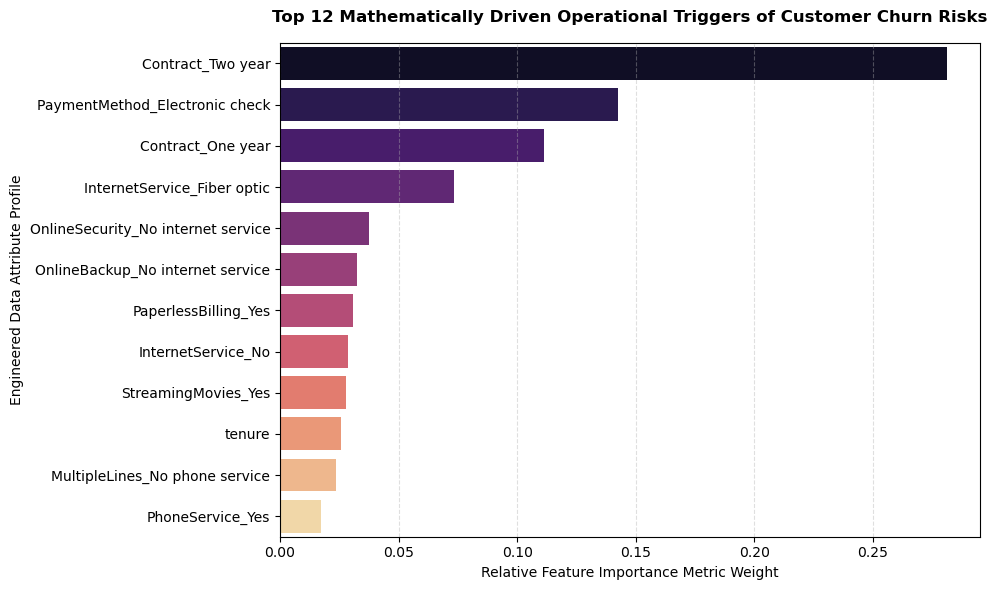

In [28]:
importances = elite_model.feature_importances_
feature_names = X.columns

# Organize weights into a clean structural data frame
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False).head(12)

# Generate high-impact horizontal profiling visualization
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='magma', hue='Feature', legend=False)
plt.title('Top 12 Mathematically Driven Operational Triggers of Customer Churn Risks', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Relative Feature Importance Metric Weight', fontsize=10)
plt.ylabel('Engineered Data Attribute Profile', fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [29]:
# 8: Production Inference Test Engine

In [30]:
def evaluate_live_churn_risk(customer_raw_dict, training_schema_cols, numerical_features, scaler_checkpoint, trained_model, custom_threshold):
    """
    Transforms a single raw customer profile, aligns its structure, and returns a calibrated risk analysis.
    """
    # 1. Package dictionary into a row data frame
    input_df = pd.DataFrame([customer_raw_dict])
    
    # 2. Extract and separate target labels if accidentally included
    for col in ['Churn', 'churn', 'Exited', 'exited']:
        if col in input_df.columns:
            input_df = input_df.drop(columns=[col])
            
    # 3. Replicate the precise training One-Hot Encoding structure
    input_encoded = pd.get_dummies(input_df)
    
    # 4. Force structural alignment with the final mathematical feature matrix
    aligned_features = pd.DataFrame(0, index=[0], columns=training_schema_cols)
    for col in aligned_features.columns:
        if col in input_encoded.columns:
            aligned_features[col] = input_encoded[col].values[0]
            
    # 5. Safely apply the standard Z-score scaling transformations onto numerical metrics
    aligned_features[numerical_features] = scaler_checkpoint.transform(aligned_features[numerical_features])
    
    # 6. Extract the precise positive-class raw probability score
    raw_probability = trained_model.predict_proba(aligned_features)[0, 1]
    
    # 7. Apply the customized dynamic cutoff sweet spot threshold
    final_decision = 1 if raw_probability >= custom_threshold else 0
    
    return {
        'Churn_Risk_Probability': round(float(raw_probability) * 100, 2),
        'Assigned_Binary_Label': final_decision,
        'Risk_Classification_Status': "🚨 HIGH RISK (Deploy Retention Vector)" if final_decision == 1 else "✅ SAFE / STABLE (Standard Management)"
    }

print("⚙️ Compiling single-row production inference simulation framework...")
print("=" * 85)

# --- SIMULATE TEST PROFILES ---

# Sample Raw Input Profile mirroring a high-risk, month-to-month consumer with high charges
sample_at_risk_customer = {
    'tenure': 2,
    'MonthlyCharges': 95.85,
    'TotalCharges': 191.70,
    'Contract': 'Month-to-month',
    'PaymentMethod': 'Electronic check',
    'PaperlessBilling': 'Yes',
    'InternetService': 'Fiber optic',
    'OnlineSecurity': 'No',
    'TechSupport': 'No'
}

# Run execution simulation pass
inference_result = evaluate_live_churn_risk(
    customer_raw_dict=sample_at_risk_customer,
    training_schema_cols=X.columns.tolist(),
    numerical_features=num_features,
    scaler_checkpoint=scaler,
    trained_model=elite_model,
    custom_threshold=best_threshold
)

print(f"👤 Simulated Live Account Assessment Results:")
print(f"   • Calibrated Leaving Probability: {inference_result['Churn_Risk_Probability']}%")
print(f"   • Assigned Output Bit Label: {inference_result['Assigned_Binary_Label']}")
print(f"   • Operational Classification Vector: {inference_result['Risk_Classification_Status']}")
print("=" * 85)

⚙️ Compiling single-row production inference simulation framework...
👤 Simulated Live Account Assessment Results:
   • Calibrated Leaving Probability: 78.7%
   • Assigned Output Bit Label: 1
   • Operational Classification Vector: 🚨 HIGH RISK (Deploy Retention Vector)


In [31]:
import joblib

monolithic_production_artifact = {
    'model_weights': elite_model,
    'scaler_weights': scaler,
    'aligned_features_schema': X.columns.tolist(),
    'numerical_features_index': num_features,
    'calibrated_decision_threshold': best_threshold
}

output_filename = "churn_prediction_production_model.pkl"
joblib.dump(monolithic_production_artifact, output_filename)

print(f"💾 SUCCESS: Unified production model file successfully written to disk!")
print(f"📁 Exported File Name: '{output_filename}'")
print("ℹ️ This singular file contains all scaling properties, structural dimensions, and model weights required for full independent runtime deployment.")

💾 SUCCESS: Unified production model file successfully written to disk!
📁 Exported File Name: 'churn_prediction_production_model.pkl'
ℹ️ This singular file contains all scaling properties, structural dimensions, and model weights required for full independent runtime deployment.
